In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [28]:
# Load the breast cancer dataset
def load_data():
    data = load_breast_cancer()
    X = data.data
    y = data.target
    feature_names = data.feature_names
    return X, y, feature_names

# PSO Particle class
class Particle:
    def __init__(self, n_features):
        # Initialize position as binary array (0 = feature not selected, 1 = feature selected)
        self.position = np.random.randint(0, 2, n_features)
        # Force at least one feature to be selected
        if np.sum(self.position) == 0:
            self.position[np.random.randint(0, n_features)] = 1
            
        self.velocity = np.random.uniform(-1, 1, n_features)
        self.best_position = self.position.copy()
        self.best_fitness = -np.inf


In [29]:
# PSO algorithm implementation
def run_pso(X, y, params, max_iter=50, classifier=SVC()):
    n_features = X.shape[1]
    n_particles = params['particles']
    w = params['inertia']  # Inertia weight
    c1 = params['c1']      # Cognitive weight
    c2 = params['c2']      # Social weight
    
    # Initialize particles
    particles = [Particle(n_features) for _ in range(n_particles)]
    global_best_position = np.zeros(n_features)  # Initialize with zeros
    global_best_fitness = -np.inf
    
    # History for convergence plot
    fitness_history = []
    
    # Initialize feature selection frequency counter
    feature_selection_freq = np.zeros(n_features)
    
    # Main PSO loop
    for iteration in range(max_iter):
        for particle in particles:
            # Convert position to boolean for feature selection
            selected_features = particle.position.astype(bool)
            
            # Evaluate fitness
            fitness = evaluate_feature_subset(X, y, selected_features, classifier)
            
            # Update particle's best position
            if fitness > particle.best_fitness:
                particle.best_fitness = fitness
                particle.best_position = particle.position.copy()
                
                # Update global best
                if fitness > global_best_fitness:
                    global_best_fitness = fitness
                    global_best_position = particle.position.copy()
        
        # Update feature selection frequency
        feature_selection_freq += global_best_position
        
        # Append best fitness for convergence plot
        fitness_history.append(global_best_fitness)
        
        # Update particle velocities and positions
        for particle in particles:
            # Cognitive component (personal best)
            r1 = np.random.uniform(0, 1, n_features)
            cognitive = c1 * r1 * (particle.best_position - particle.position)
            
            # Social component (global best)
            r2 = np.random.uniform(0, 1, n_features)
            social = c2 * r2 * (global_best_position - particle.position)
            
            # Update velocity with inertia
            particle.velocity = w * particle.velocity + cognitive + social
            
            # Sigmoid function to convert velocity to probability
            sigmoid = 1 / (1 + np.exp(-particle.velocity))
            
            # Update position based on probability
            random_values = np.random.uniform(0, 1, n_features)
            particle.position = np.where(random_values < sigmoid, 1, 0)
            
            # Force at least one feature to be selected
            if np.sum(particle.position) == 0:
                particle.position[np.random.randint(0, n_features)] = 1
    
    # Normalize feature selection frequency
    feature_selection_freq = feature_selection_freq / max_iter
    
    return global_best_position.astype(bool), global_best_fitness, fitness_history, feature_selection_freq

In [30]:
# Function to evaluate feature subset with cross-validation
def evaluate_feature_subset(X, y, selected_features, classifier=SVC()):
    if not np.any(selected_features):
        return 0.0
    
    X_selected = X[:, selected_features]
    
    # 5-fold cross validation for more robust evaluation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(classifier, X_selected, y, cv=cv, scoring='accuracy')
    
    # We want both high accuracy and fewer features
    feature_penalty = 0.1 * (np.sum(selected_features) / len(selected_features))
    
    return np.mean(scores) - feature_penalty

In [31]:
def compare_methods(X, y, pso_features, f_score_threshold=0.05, rf_min_features=5):
    results = {}
    feature_counts = {}
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # All features (no selection)
    clf = SVC()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    results['All Features'] = accuracy
    feature_counts['All Features'] = X.shape[1]
    
    # F-score based selection (adaptive threshold instead of fixed k=4)
    selector = SelectKBest(f_classif, k='all')
    X_train_f = selector.fit_transform(X_train, y_train)
    p_values = selector.pvalues_
    selected_f_features = p_values < f_score_threshold  # Select based on significance
    X_train_f = X_train[:, selected_f_features]
    X_test_f = X_test[:, selected_f_features]
    
    if np.sum(selected_f_features) < rf_min_features:  # Ensure minimum features
        selected_f_features = np.argsort(p_values)[:rf_min_features]
        X_train_f = X_train[:, selected_f_features]
        X_test_f = X_test[:, selected_f_features]
    
    clf.fit(X_train_f, y_train)
    y_pred = clf.predict(X_test_f)
    accuracy = np.mean(y_pred == y_test)
    results['F-Score'] = accuracy
    feature_counts['F-Score'] = np.sum(selected_f_features)
    
    # Random Forest importance (dynamic threshold instead of fixed top-4)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    importance = rf.feature_importances_
    
    # Adaptive feature selection: Select features with importance > mean
    rf_features = importance > np.mean(importance)
    
    if np.sum(rf_features) < rf_min_features:  # Ensure minimum features
        rf_features = np.argsort(importance)[-rf_min_features:]
    
    X_train_rf = X_train[:, rf_features]
    X_test_rf = X_test[:, rf_features]
    clf.fit(X_train_rf, y_train)
    y_pred = clf.predict(X_test_rf)
    accuracy = np.mean(y_pred == y_test)
    results['Random Forest'] = accuracy
    feature_counts['Random Forest'] = np.sum(rf_features)
    
    # PSO selection
    X_train_pso = X_train[:, pso_features]
    X_test_pso = X_test[:, pso_features]
    clf.fit(X_train_pso, y_train)
    y_pred = clf.predict(X_test_pso)
    accuracy = np.mean(y_pred == y_test)
    results['PSO'] = accuracy
    feature_counts['PSO'] = np.sum(pso_features)
    
    return results, feature_counts, selected_f_features, rf_features

In [24]:
# Function to visualize convergence
def plot_convergence(fitness_history):
    plt.figure(figsize=(10, 6))
    plt.plot(fitness_history, 'b-', linewidth=2)
    plt.title('PSO Convergence Curve')
    plt.xlabel('Iteration')
    plt.ylabel('Best Fitness')
    plt.grid(True)
    plt.show()

# Function to visualize feature selection frequency
def plot_feature_importance(feature_selection_freq, feature_names, selected_features):
    # For selected features only
    selected_indices = np.where(selected_features)[0]
    selected_names = feature_names[selected_indices]
    selected_freq = feature_selection_freq[selected_indices]
    
    # Sort by frequency
    sorted_idx = np.argsort(selected_freq)[::-1]  # Descending
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(sorted_idx)), selected_freq[sorted_idx], color='lightblue')
    plt.yticks(range(len(sorted_idx)), selected_names[sorted_idx])
    plt.title('Selected Features Importance')
    plt.xlabel('Selection Frequency')
    plt.tight_layout()
    plt.show()
    
    # All features ranked by importance
    plt.figure(figsize=(14, 10))
    sorted_idx_all = np.argsort(feature_selection_freq)[::-1]  # Descending
    plt.barh(range(len(sorted_idx_all)), feature_selection_freq[sorted_idx_all], 
             color=['lightblue' if i in selected_indices else 'lightgray' for i in sorted_idx_all])
    plt.yticks(range(len(sorted_idx_all)), feature_names[sorted_idx_all])
    plt.title('All Features Ranked by Importance (Selected Features in Blue)')
    plt.xlabel('Selection Frequency')
    plt.tight_layout()
    plt.show()


In [25]:
# Function for comprehensive evaluation of final model - with 4-digit precision
def evaluate_final_model(X, y, selected_features):
    X_selected = X[:, selected_features]
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
    
    # Train model
    clf = SVC(probability=True)
    clf.fit(X_train, y_train)
    
    # Predictions
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    # Calculate metrics with 4-digit precision
    print("\nClassification Report for PSO-Selected Features:")
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Format with 4 digits
    print(f"Accuracy: {report['accuracy']:.4f}")
    print(f"Precision: {report['weighted avg']['precision']:.4f}")
    print(f"Recall: {report['weighted avg']['recall']:.4f}")
    print(f"F1-score: {report['weighted avg']['f1-score']:.4f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    print(f"AUC: {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('PSO Model - Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    
    # ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('PSO Model - ROC Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    return clf, roc_auc

Dataset shape: (569, 30)
Number of classes: 2

--- RUNNING PSO FEATURE SELECTION ---
PSO parameters: {'particles': 30, 'inertia': 0.7, 'c1': 1.5, 'c2': 1.5}

PSO Optimization Results:
Best fitness score: 0.9519
Number of selected features: 6 out of 30

Selected features:
- mean concave points
- mean symmetry
- compactness error
- worst texture
- worst perimeter
- worst compactness

PSO Convergence Plot:


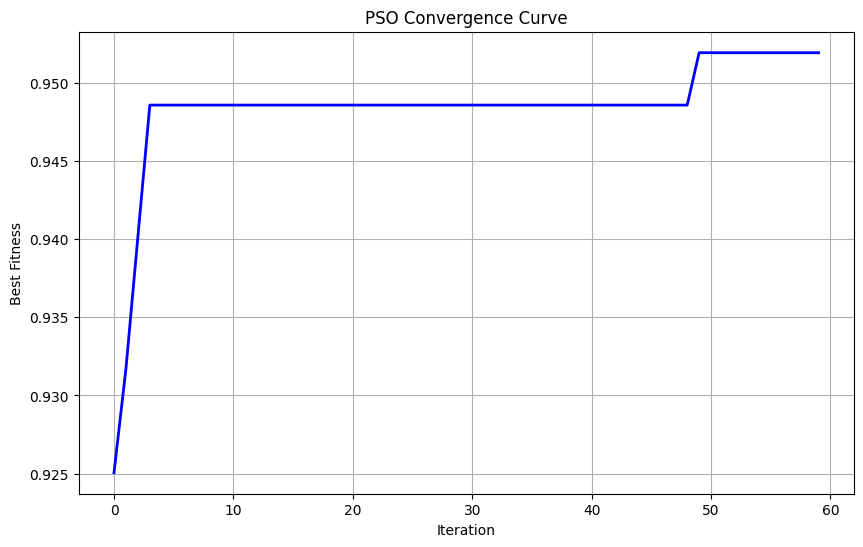


Feature Importance Based on PSO:


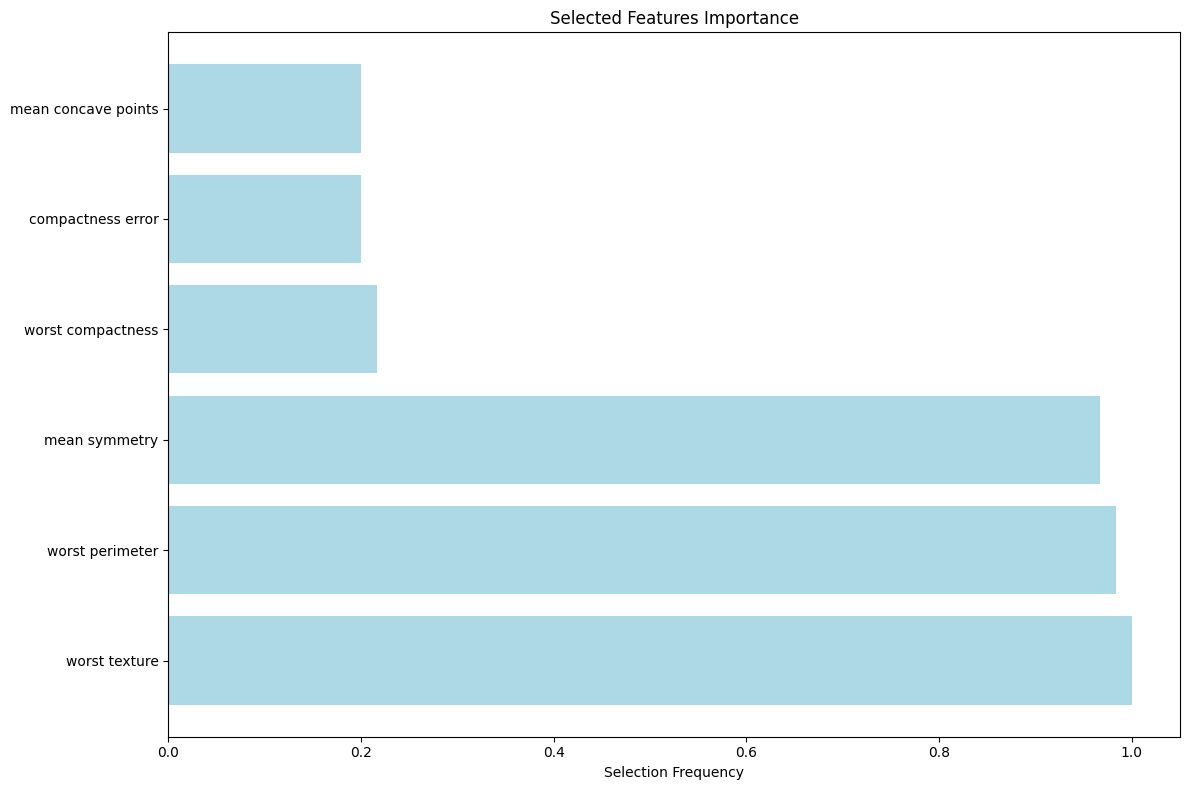

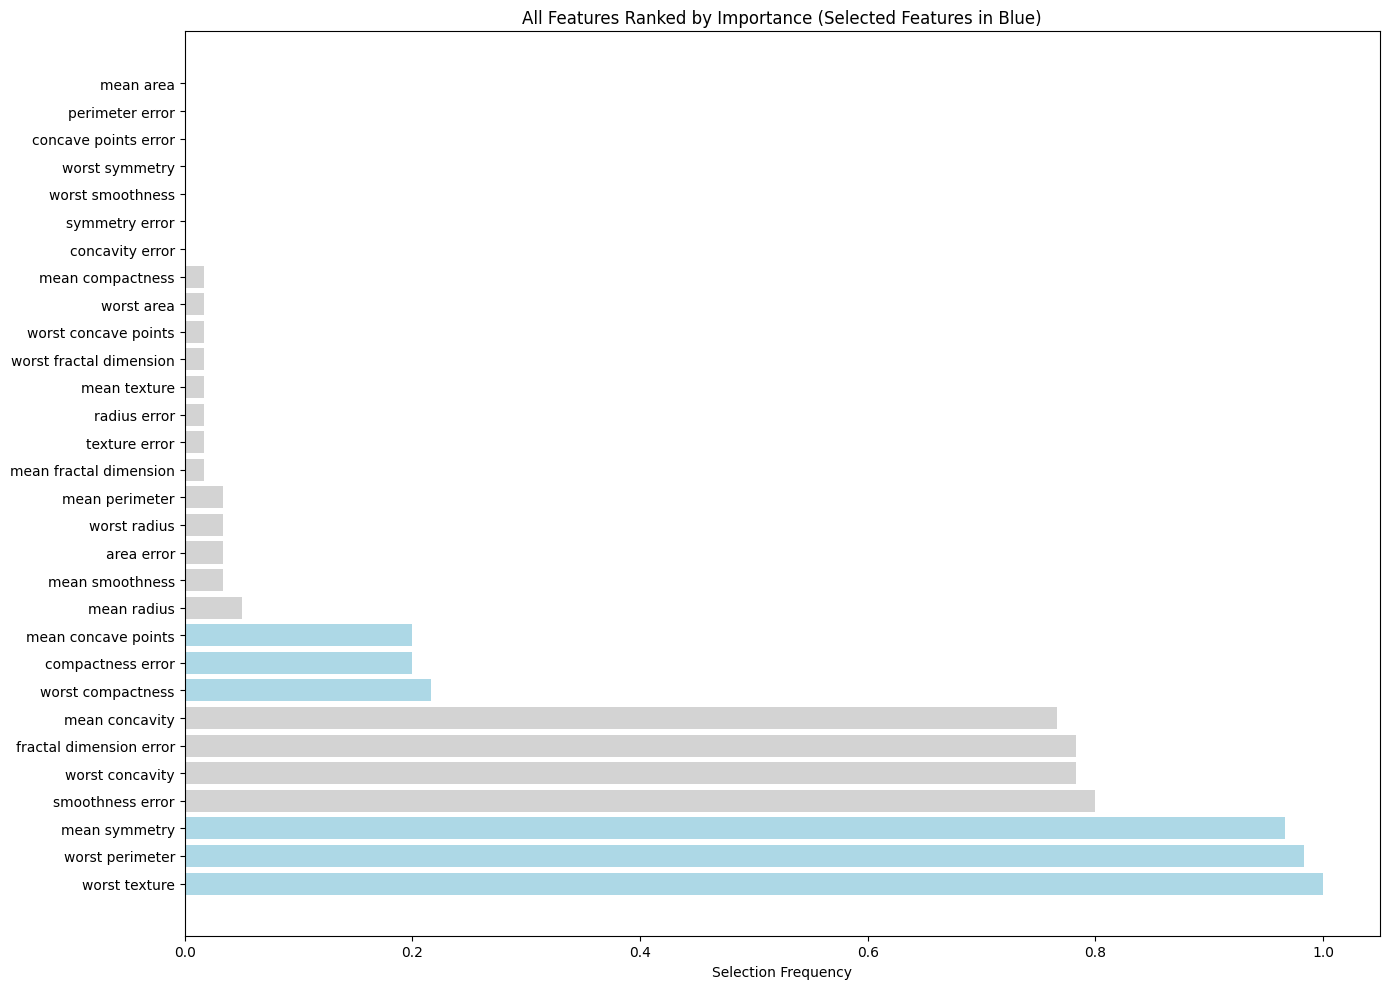


Evaluating PSO model performance:

Classification Report for PSO-Selected Features:
Accuracy: 0.9649
Precision: 0.9649
Recall: 0.9649
F1-score: 0.9649
AUC: 0.9967


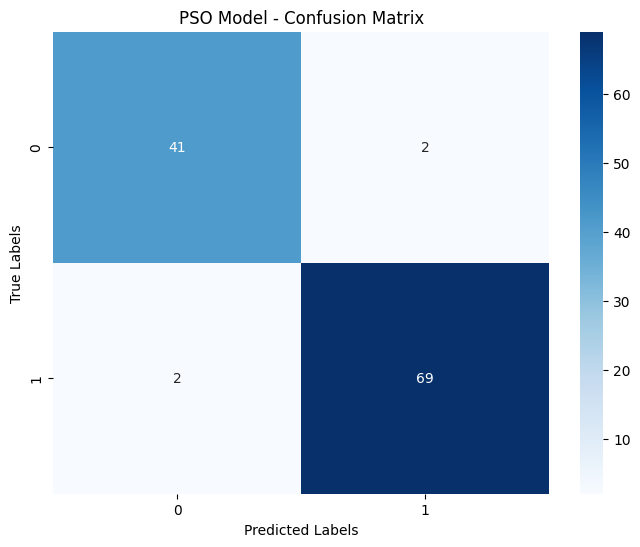

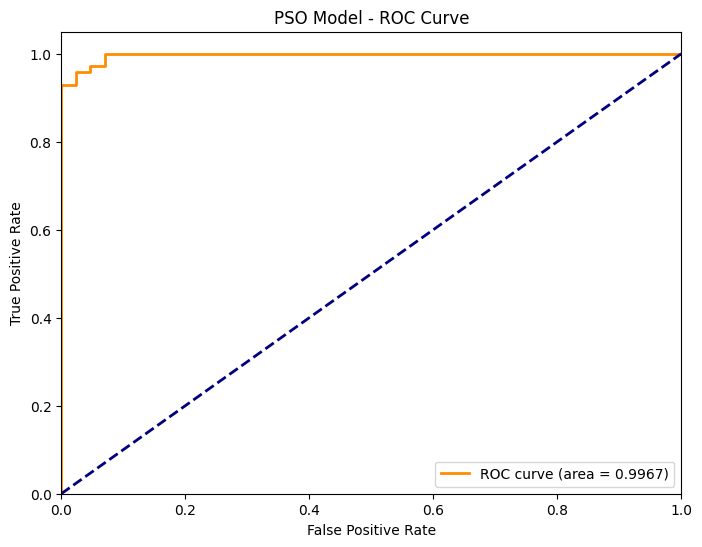


--- COMPARING WITH OTHER FEATURE SELECTION METHODS ---

Performance comparison (Accuracy):
All Features: 0.9737 (using 30 features)
F-Score: 0.9737 (using 25 features)
Random Forest: 0.9649 (using 9 features)
PSO: 0.9649 (using 6 features)


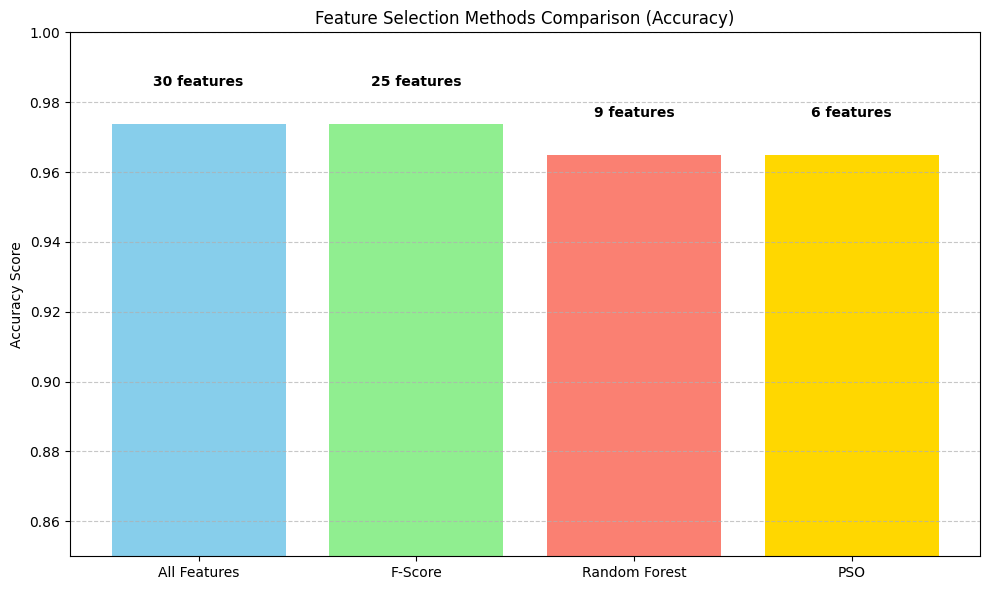

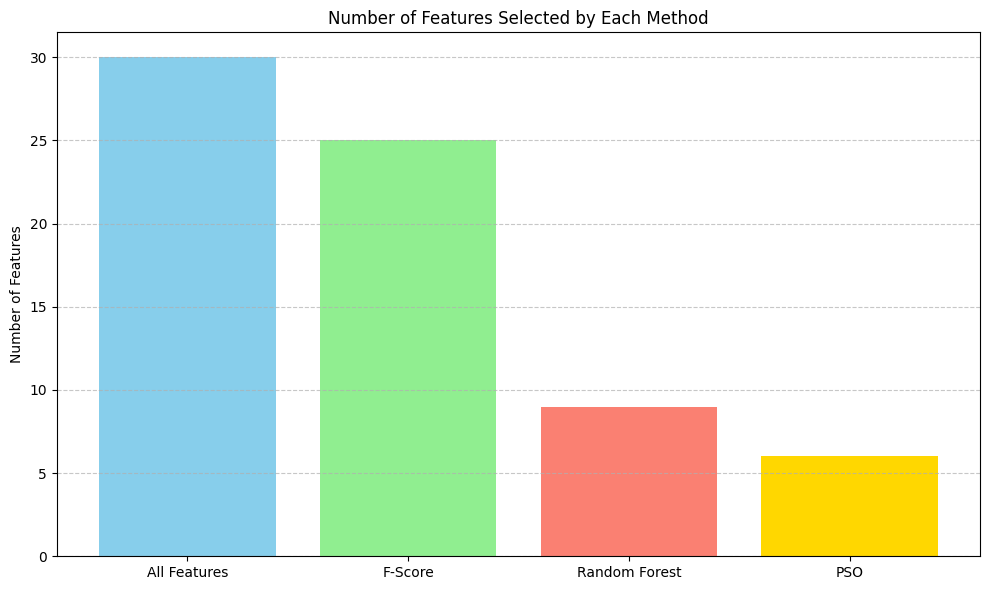


Results in table format:
Method               Accuracy (%)    Features Used  
--------------------------------------------------
PSO-based            96.5            6              
All Features         97.4            30             
F-score              97.4            25             
Random Forest        96.5            9              
--------------------------------------------------


In [26]:
# Update parameter settings to improve solution
def main():
    # Load data
    X, y, feature_names = load_data()
    feature_names = np.array(feature_names)
    
    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Number of classes: {np.unique(y).shape[0]}")
    
    # Adjusted PSO parameters for better convergence
    print("\n--- RUNNING PSO FEATURE SELECTION ---")
    params = {
        'particles': 30,  # Increased particle count
        'inertia': 0.7,
        'c1': 1.5,
        'c2': 1.5  # Increased social component
    }
    
    print(f"PSO parameters: {params}")
    best_features, best_fitness, fitness_history, feature_selection_freq = run_pso(X, y, params, max_iter=60)  # Increased iterations
    
    # Display results
    print(f"\nPSO Optimization Results:")
    print(f"Best fitness score: {best_fitness:.4f}")
    print(f"Number of selected features: {np.sum(best_features)} out of {X.shape[1]}")
    print("\nSelected features:")
    for i, selected in enumerate(best_features):
        if selected:
            print(f"- {feature_names[i]}")
    
    # Show PSO convergence
    print("\nPSO Convergence Plot:")
    plot_convergence(fitness_history)
    
    # Show feature importance from PSO
    print("\nFeature Importance Based on PSO:")
    plot_feature_importance(feature_selection_freq, feature_names, best_features)
    
    # Evaluate PSO model performance
    print("\nEvaluating PSO model performance:")
    model, pso_auc = evaluate_final_model(X, y, best_features)
    
    # Compare with other methods using accuracy instead of AUC
    print("\n--- COMPARING WITH OTHER FEATURE SELECTION METHODS ---")
    results, feature_counts, f_features, rf_features = compare_methods(X, y, best_features)
    
    print("\nPerformance comparison (Accuracy):")
    for method, score in results.items():
        print(f"{method}: {score:.4f} (using {feature_counts[method]} features)")
    
    # Plot performance comparison
    plt.figure(figsize=(10, 6))
    methods = list(results.keys())
    scores = [results[method] for method in methods]
    
    # Create bars with different colors
    colors = ['skyblue', 'lightgreen', 'salmon', 'gold']
    plt.bar(methods, scores, color=colors)
    
    # Add feature counts as annotations
    for i, method in enumerate(methods):
        plt.text(i, scores[i] + 0.01, f"{feature_counts[method]} features", 
                 ha='center', va='bottom', fontweight='bold')
    
    plt.title('Feature Selection Methods Comparison (Accuracy)')
    plt.ylabel('Accuracy Score')
    plt.ylim([0.85, 1.0])  # Adjusted for accuracy values
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Plot feature counts comparison
    plt.figure(figsize=(10, 6))
    plt.bar(methods, [feature_counts[method] for method in methods], color=colors)
    plt.title('Number of Features Selected by Each Method')
    plt.ylabel('Number of Features')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Print table-ready results
    print("\nResults in table format:")
    print("{:<20} {:<15} {:<15}".format("Method", "Accuracy (%)", "Features Used"))
    print("-" * 50)
    print("{:<20} {:<15.1f} {:<15}".format("PSO-based", results['PSO'] * 100, feature_counts['PSO']))
    print("{:<20} {:<15.1f} {:<15}".format("All Features", results['All Features'] * 100, feature_counts['All Features']))
    print("{:<20} {:<15.1f} {:<15}".format("F-score", results['F-Score'] * 100, feature_counts['F-Score']))
    print("{:<20} {:<15.1f} {:<15}".format("Random Forest", results['Random Forest'] * 100, feature_counts['Random Forest']))
    print("-" * 50)


if __name__ == "__main__":
    main()